In [121]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12345)

In [123]:
def count_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = data[(data < lower) | (data > upper)]
    return len(outliers)

In [125]:
sample_sizes = [20, 100]
n_iterations = 1000

distributions = {
    'Нормальное N(0,1)': lambda n: np.random.normal(0, 1, n),
    'Коши C(0,1)': lambda n: np.random.standard_cauchy(n),
    'Лапласа L(0, 1/sqrt(2))': lambda n: np.random.laplace(0, 1/np.sqrt(2), n),
    'Пуассона P(5)': lambda n: np.random.poisson(5, n),
    'Равномерное U(-sqrt(3),sqrt(3))': lambda n: np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
}

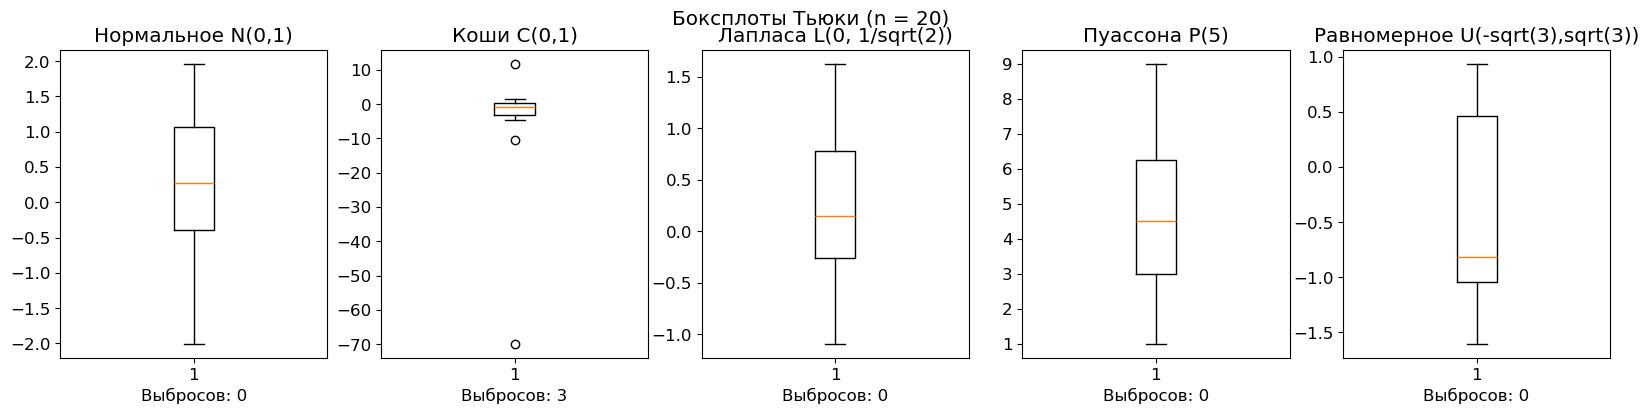

In [127]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (name, gen) in enumerate(distributions.items()):
    sample = gen(20)
    axes[idx].boxplot(sample)
    axes[idx].set_title(name)
    axes[idx].set_xlabel(f'Выбросов: {count_outliers(sample)}')

plt.suptitle('Боксплоты Тьюки (n = 20)')
plt.show()

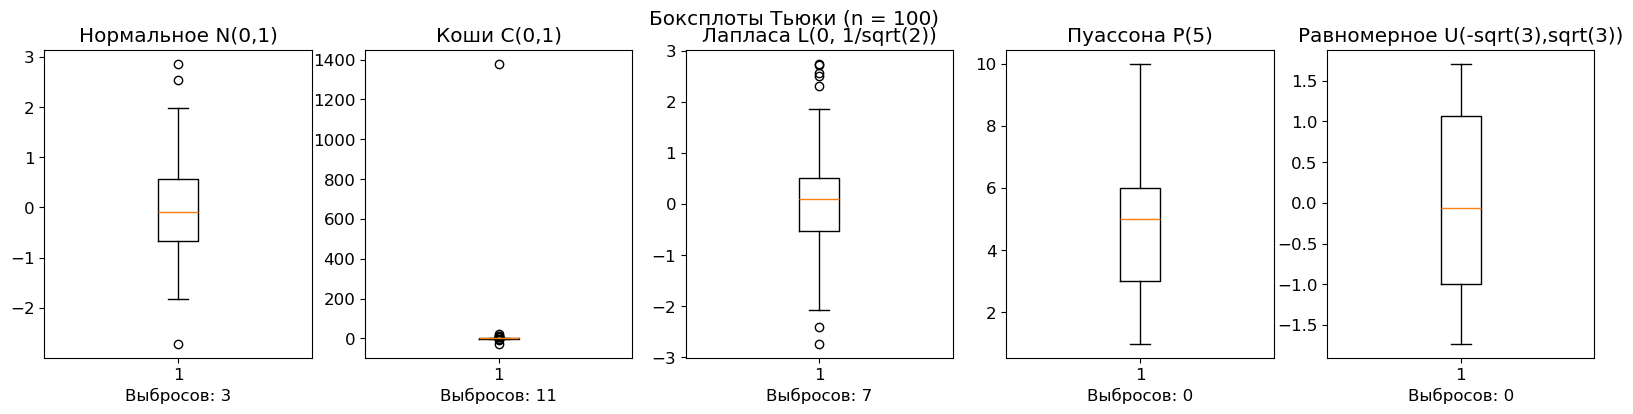

In [129]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (name, gen) in enumerate(distributions.items()):
    sample = gen(100)
    axes[idx].boxplot(sample)
    axes[idx].set_title(name)
    axes[idx].set_xlabel(f'Выбросов: {count_outliers(sample)}')

plt.suptitle('Боксплоты Тьюки (n = 100)')
plt.show()

In [131]:
print('СРЕДНЯЯ ДОЛЯ ВЫБРОСОВ (1000 экспериментов)')
print(f"{'Распределение':<30} {'n=20':>10} {'n=100':>10}")
print('-'*52)

for name, gen in distributions.items():
    fractions_20 = []
    fractions_100 = []
    
    for _ in range(n_iterations):
        fractions_20.append(count_outliers(gen(20)) / 20)
        fractions_100.append(count_outliers(gen(100)) / 100)
    
    mean_20 = np.mean(fractions_20)
    mean_100 = np.mean(fractions_100)
    
    print(f"{name:<30} {mean_20:>10.4f} {mean_100:>10.4f}")

СРЕДНЯЯ ДОЛЯ ВЫБРОСОВ (1000 экспериментов)
Распределение                        n=20      n=100
----------------------------------------------------
Нормальное N(0,1)                  0.0225     0.0106
Коши C(0,1)                        0.1488     0.1550
Лапласа L(0, 1/sqrt(2))            0.0710     0.0656
Пуассона P(5)                      0.0257     0.0140
Равномерное U(-sqrt(3),sqrt(3))     0.0035     0.0000
